In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv")

In [4]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Blood _Donation_Prediction.ipynb',
 'Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv',
 'Warm_Up_Predict_Blood_Donations_-_Traning_Data.xlsx']

In [5]:
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


In [6]:
df.tail()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
571,698,23,1,250,23,0
572,433,16,3,750,86,0
573,360,21,2,500,52,0
574,541,39,1,250,39,0
575,74,72,1,250,72,0


In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (576, 6)


In [8]:
df.columns

Index(['Unnamed: 0', 'Months since Last Donation', 'Number of Donations',
       'Total Volume Donated (c.c.)', 'Months since First Donation',
       'Made Donation in March 2007'],
      dtype='object')

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,576.0,374.034722,216.947773,0.0,183.75,375.5,562.50,747.0
Months since Last Donation,576.0,9.439236,8.175454,0.0,2.00,7.0,14.00,74.0
Number of Donations,576.0,5.427083,5.740010,1.0,2.00,4.0,7.00,50.0
Total Volume Donated (c.c.),576.0,1356.770833,1435.002556,250.0,500.00,1000.0,1750.00,12500.0
Months since First Donation,576.0,34.050347,24.227672,2.0,16.00,28.0,49.25,98.0
Made Donation in March 2007,576.0,0.239583,0.427200,0.0,0.00,0.0,0.00,1.0


In [10]:
df.isnull().sum()

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

Unnamed: 0                     int64
Months since Last Donation     int64
Number of Donations            int64
Total Volume Donated (c.c.)    int64
Months since First Donation    int64
Made Donation in March 2007    int64
dtype: object

In [13]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [14]:
df.head()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


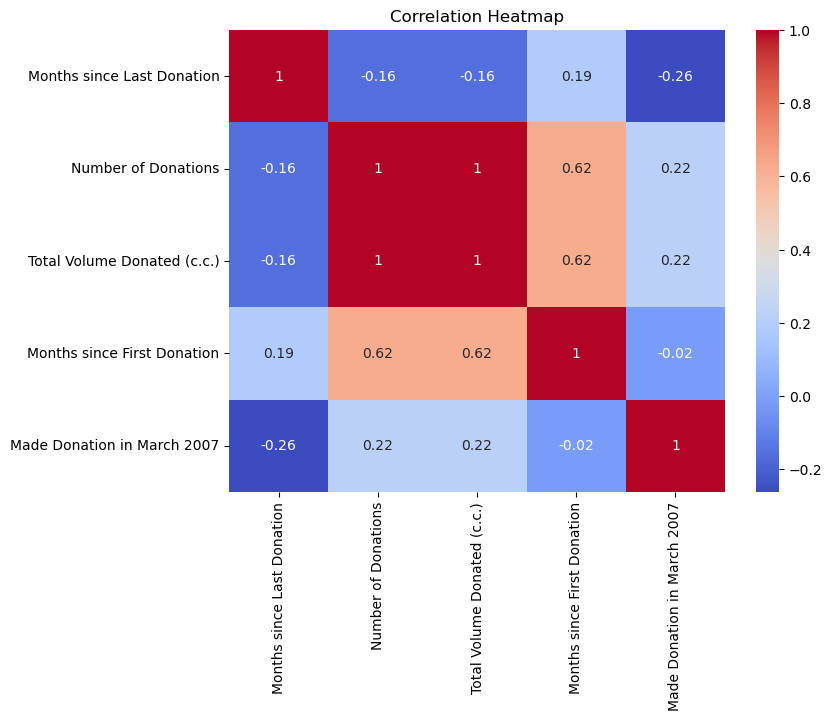

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

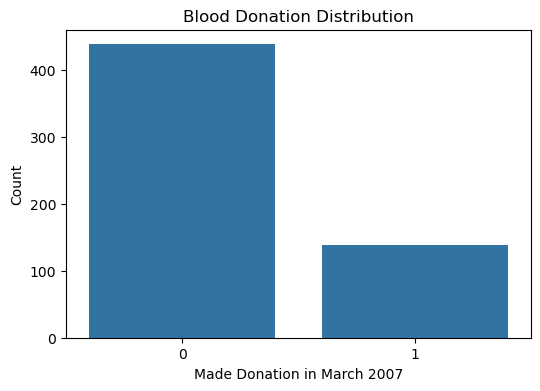

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="Made Donation in March 2007", data=df)

plt.title("Blood Donation Distribution")
plt.xlabel("Made Donation in March 2007")
plt.ylabel("Count")

plt.show()

The target variable shows the distribution of donors who donated and did not donate blood in March 2007.

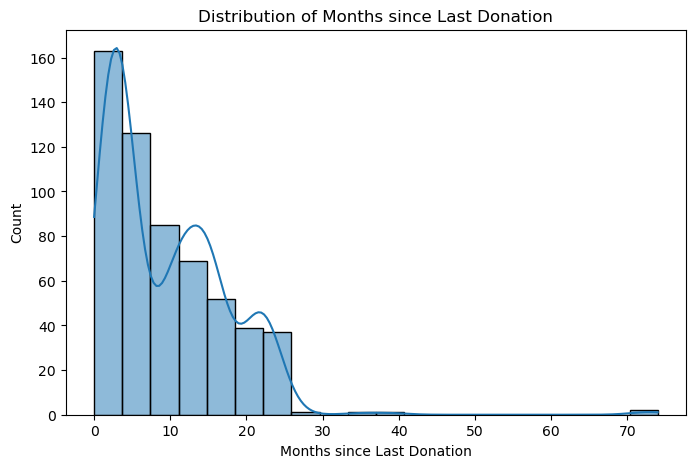

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["Months since Last Donation"], bins=20, kde=True)

plt.title("Distribution of Months since Last Donation")

plt.show()

Most donors made their last donation within a shorter time period, while fewer donors have a long gap since their last donation.

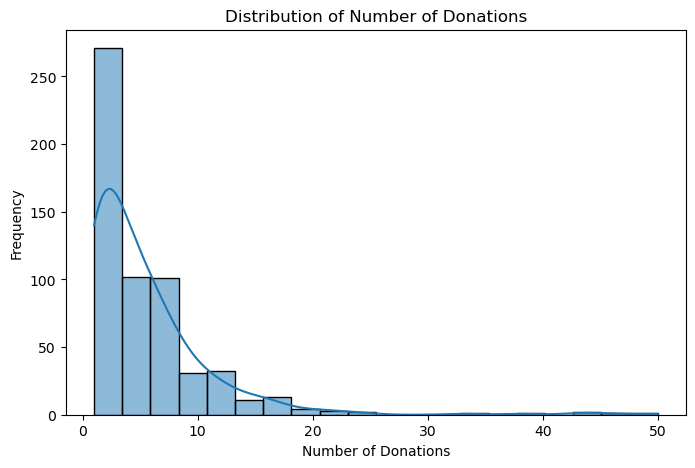

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Number of Donations"], bins=20, kde=True)

plt.title("Distribution of Number of Donations")
plt.xlabel("Number of Donations")
plt.ylabel("Frequency")

plt.show()

Most donors have donated only a few times, while a smaller number of donors have donated frequently.

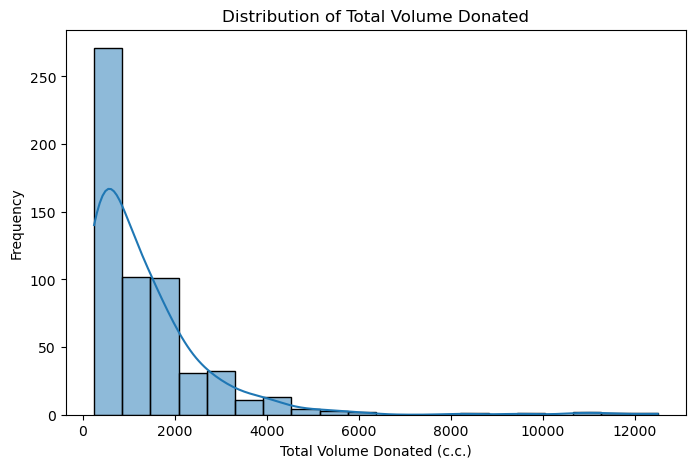

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["Total Volume Donated (c.c.)"], bins=20, kde=True)

plt.title("Distribution of Total Volume Donated")
plt.xlabel("Total Volume Donated (c.c.)")
plt.ylabel("Frequency")

plt.show()

Most donors have donated a lower total volume of blood, while only a few donors have donated a large total volume.

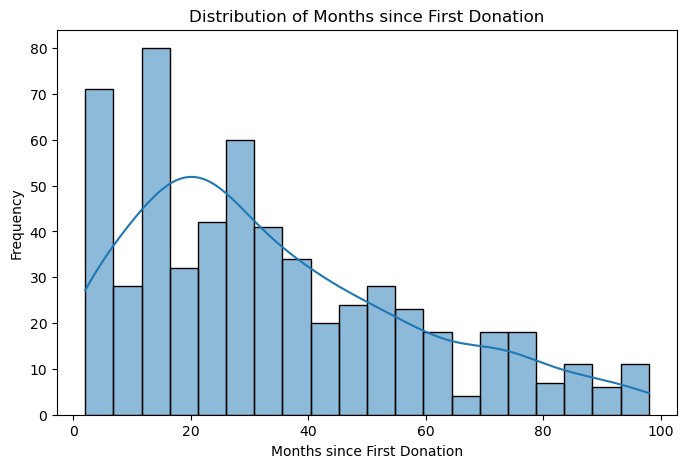

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["Months since First Donation"], bins=20, kde=True)

plt.title("Distribution of Months since First Donation")
plt.xlabel("Months since First Donation")
plt.ylabel("Frequency")

plt.show()

The dataset contains both new and long-term donors, with many donors having started donating relatively recently.

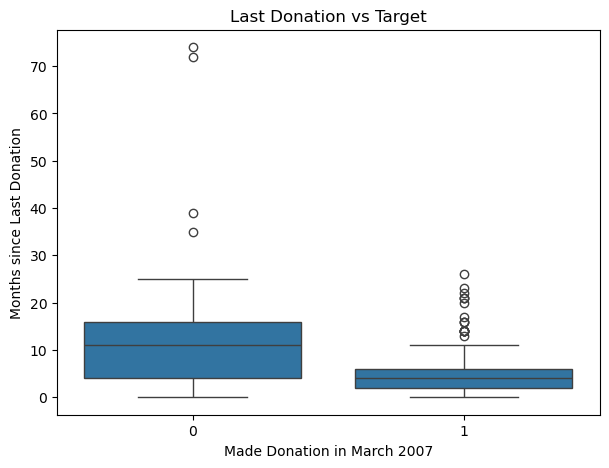

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Made Donation in March 2007",
            y="Months since Last Donation",
            data=df)

plt.title("Last Donation vs Target")
plt.show()

Donors who donated in March 2007 generally have fewer months since their last donation compared to those who did not donate.

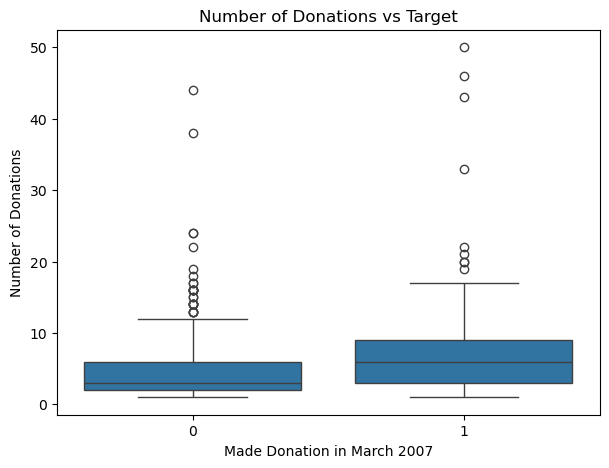

In [22]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Made Donation in March 2007",
            y="Number of Donations",
            data=df)

plt.title("Number of Donations vs Target")
plt.xlabel("Made Donation in March 2007")
plt.ylabel("Number of Donations")

plt.show()

Donors who donated in March 2007 generally have a higher number of previous donations than those who did not donate.

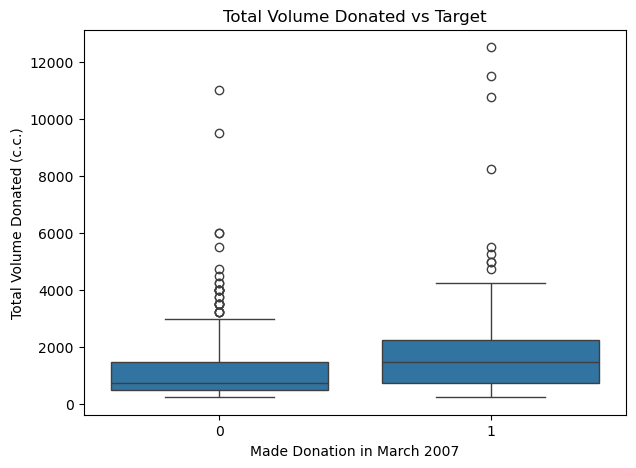

In [23]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Made Donation in March 2007",
            y="Total Volume Donated (c.c.)",
            data=df)

plt.title("Total Volume Donated vs Target")
plt.xlabel("Made Donation in March 2007")
plt.ylabel("Total Volume Donated (c.c.)")

plt.show()

Donors who donated in March 2007 tend to have donated a larger total volume of blood compared to those who did not donate.

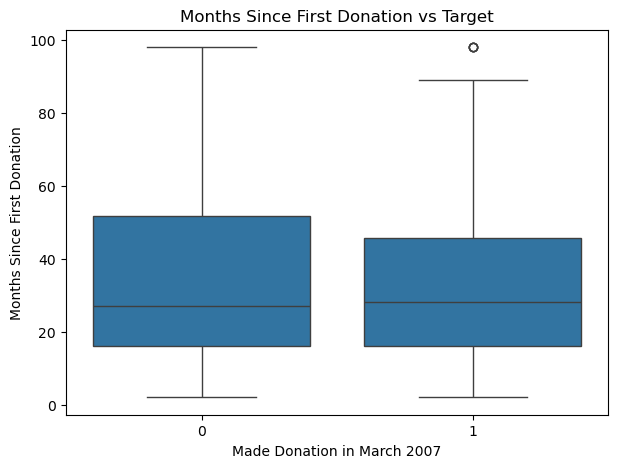

In [24]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Made Donation in March 2007",
            y="Months since First Donation",
            data=df)

plt.title("Months Since First Donation vs Target")
plt.xlabel("Made Donation in March 2007")
plt.ylabel("Months Since First Donation")

plt.show()

Donors with a longer donation history are generally more likely to donate again.

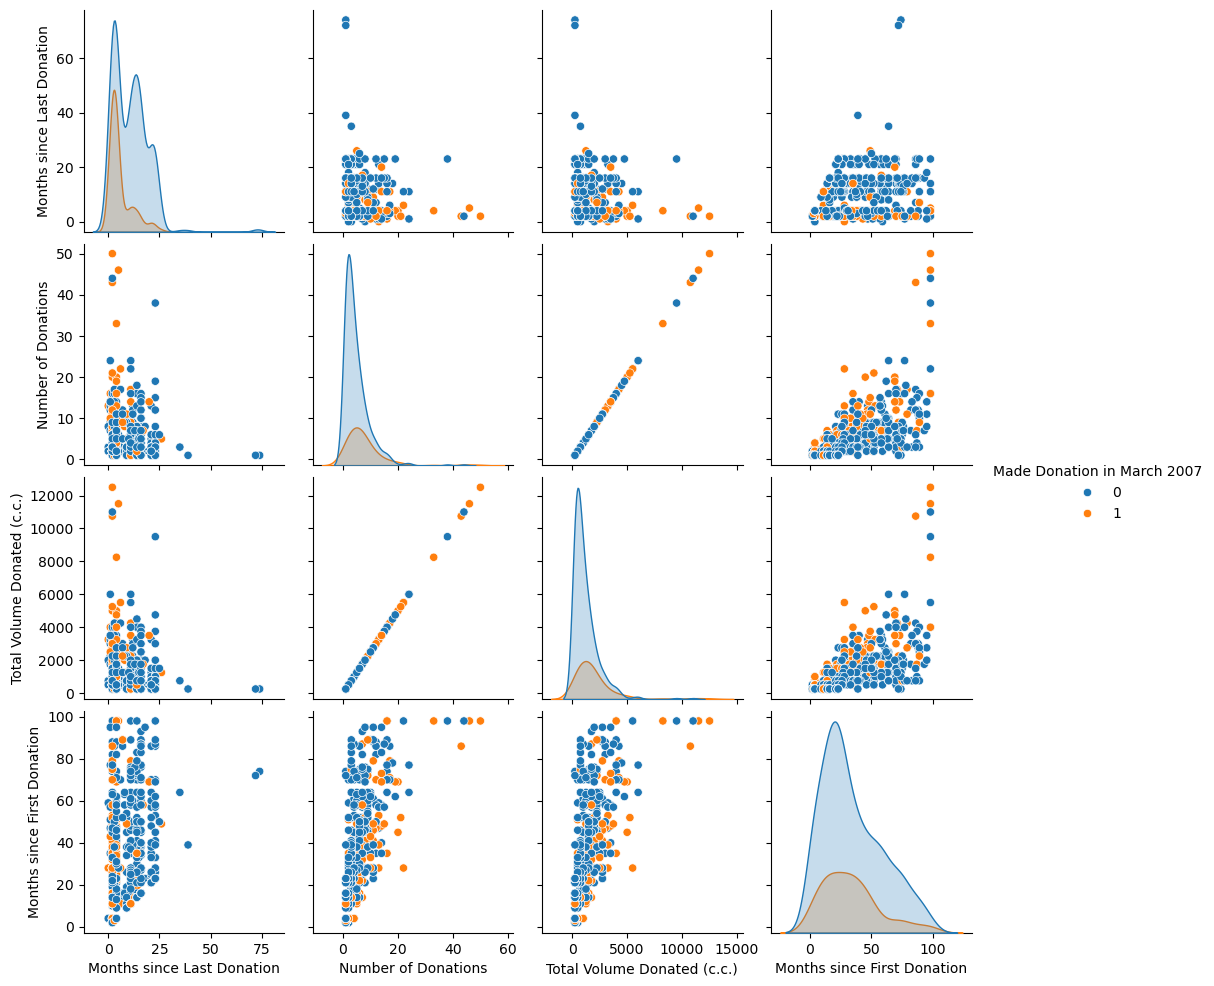

In [25]:
sns.pairplot(df, hue="Made Donation in March 2007")
plt.show()

The pairplot shows the relationship among the numerical features. Previous donation behavior appears to influence whether a donor donates again.

In [26]:
X = df.drop("Made Donation in March 2007", axis=1)
y = df["Made Donation in March 2007"]

In [27]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (576, 4)
Target Shape: (576,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (460, 4)
Testing Data: (116, 4)


In [30]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
lr_pred = lr.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Accuracy: 0.75

Confusion Matrix:

[[86  1]
 [28  1]]

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.99      0.86        87
           1       0.50      0.03      0.06        29

    accuracy                           0.75       116
   macro avg       0.63      0.51      0.46       116
weighted avg       0.69      0.75      0.66       116



In [33]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
dt_pred = dt.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

Accuracy: 0.7413793103448276

Confusion Matrix:

[[82  5]
 [25  4]]

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.94      0.85        87
           1       0.44      0.14      0.21        29

    accuracy                           0.74       116
   macro avg       0.61      0.54      0.53       116
weighted avg       0.69      0.74      0.69       116



In [36]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
rf_pred = rf.predict(X_test)

In [38]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Accuracy: 0.75

Confusion Matrix:

[[74 13]
 [16 13]]

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.85      0.84        87
           1       0.50      0.45      0.47        29

    accuracy                           0.75       116
   macro avg       0.66      0.65      0.65       116
weighted avg       0.74      0.75      0.75       116



In [39]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ab.fit(X_train, y_train)

ab_pred = ab.predict(X_test)

print("AdaBoost Classifier")
print("Accuracy:", accuracy_score(y_test, ab_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, ab_pred))
print("\nClassification Report")
print(classification_report(y_test, ab_pred))

AdaBoost Classifier
Accuracy: 0.75

Confusion Matrix
[[85  2]
 [27  2]]

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.98      0.85        87
           1       0.50      0.07      0.12        29

    accuracy                           0.75       116
   macro avg       0.63      0.52      0.49       116
weighted avg       0.69      0.75      0.67       116



In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Classifier")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, gb_pred))
print("\nClassification Report")
print(classification_report(y_test, gb_pred))

Gradient Boosting Classifier
Accuracy: 0.7413793103448276

Confusion Matrix
[[75 12]
 [18 11]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.86      0.83        87
           1       0.48      0.38      0.42        29

    accuracy                           0.74       116
   macro avg       0.64      0.62      0.63       116
weighted avg       0.72      0.74      0.73       116



In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ab_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.750000
2,Random Forest,0.750000
3,AdaBoost,0.750000
1,Decision Tree,0.741379
4,Gradient Boosting,0.741379


# Best Model for Production

Five classification models were developed and evaluated:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. AdaBoost Classifier
5. Gradient Boosting Classifier

Based on the model comparison, Logistic Regression, Random Forest Classifier, and AdaBoost Classifier achieved the highest accuracy of 75%. Among these, the Random Forest Classifier is recommended for production because it is a robust ensemble model that provides reliable performance and generalizes well on unseen data.

Therefore, the Random Forest Classifier is selected as the best model for predicting repeat blood donors.

## Challenges Faced

1. The dataset contained limited donor information, which made prediction more challenging.

2. Selecting the most relevant features for predicting repeat blood donation required careful data analysis.

3. Multiple classification models were trained and compared to identify the best-performing model.

4. Some models achieved similar accuracy, so additional evaluation was needed to choose the most suitable model for production.

5. Ensuring the model generalized well without overfitting was an important challenge during model development.

## Conclusion

This project successfully analyzed blood donor data and developed machine learning models to predict whether a donor is likely to donate blood again. Five classification models were trained and evaluated using accuracy. Logistic Regression, Random Forest Classifier, and AdaBoost Classifier achieved the highest accuracy of 75%. Among these, the Random Forest Classifier was selected as the best model for production because of its robustness and reliable performance. The developed model can help blood banks identify potential repeat donors, improve donation planning, and support efficient blood inventory management.